<a href="https://colab.research.google.com/github/Indra-sekhar/CPP-STL/blob/main/ML_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Metric: Euclidean
Distances: [25.         33.54101966 68.00735254 14.14213562 61.03277808 47.16990566
 45.27692569]
Top-k Neighbors: [(np.float64(14.142135623730951), 3, 'Red'), (np.float64(25.0), 0, 'Red'), (np.float64(33.54101966249684), 1, 'Blue'), (np.float64(45.27692569068709), 6, 'Blue'), (np.float64(47.16990566028302), 5, 'Red')]
Prediction: Red (Class 0)


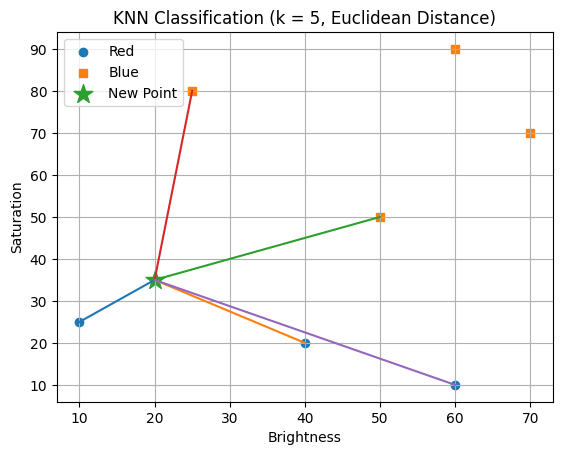

In [ ]:
# 3a.KNN Classification

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# -----------------------------
# Sample Color Dataset
# [Brightness, Saturation, Label]
# Label: 0 = Red, 1 = Blue
# -----------------------------
data = np.array([
    [40, 20, 0],  # Red
    [50, 50, 1],  # Blue
    [60, 90, 1],  # Blue
    [10, 25, 0],  # Red
    [70, 70, 1],  # Blue
    [60, 10, 0],  # Red
    [25, 80, 1]   # Blue
])

# Features and labels
X = data[:, :-1]
Y = data[:, -1]

# Label mapping
label_map = {0: "Red", 1: "Blue"}

# New data point
new_point = np.array([[20, 35]])

# -----------------------------
# KNN using Euclidean Distance
# -----------------------------
distances = pairwise_distances(X, new_point, metric='euclidean').flatten()

# Combine distance info
distance_info = [
    (distances[i], i, label_map[Y[i]])
    for i in range(len(distances))
]

# Sort by distance
distance_info.sort(key=lambda x: x[0])

# Select k nearest neighbors
k = 5
top_k = distance_info[:k]

# Majority voting
labels = [Y[i] for _, i, _ in top_k]
predicted_label = max(set(labels), key=labels.count)

#                                                                                                                                                                                                            -----------------------------
# OUTPUT
# -----------------------------
print("Metric: Euclidean")
print("Distances:", distances)
print("Top-k Neighbors:", top_k)
print(f"Prediction: {label_map[predicted_label]} (Class {predicted_label})")

# -----------------------------
# PLOT
# -----------------------------
plt.figure()

# Plot Red points
plt.scatter(
    X[Y == 0][:, 0],
    X[Y == 0][:, 1],
    marker='o',
    label='Red'
)

# Plot Blue points
plt.scatter(
    X[Y == 1][:, 0],
    X[Y == 1][:, 1],
    marker='s',
    label='Blue'
)

# Plot new point
plt.scatter(
    new_point[0, 0],
    new_point[0, 1],
    marker='*',
    s=200,
    label='New Point'
)
# Draw lines to k nearest neighbors
for dist, idx, _ in top_k:
    plt.plot(
        [new_point[0, 0], X[idx, 0]],
        [new_point[0, 1], X[idx, 1]]
    )
# Labels and title
plt.xlabel("Brightness")
plt.ylabel("Saturation")
plt.title("KNN Classification (k = 5, Euclidean Distance)")
plt.legend()
plt.grid()

plt.show()

Metric: Euclidean Distance
Distances: [20. 30. 40. 10. 50. 40.  5.]
k nearest indices: [6 3 0 1 2]
Predicted Saturation: 53.0


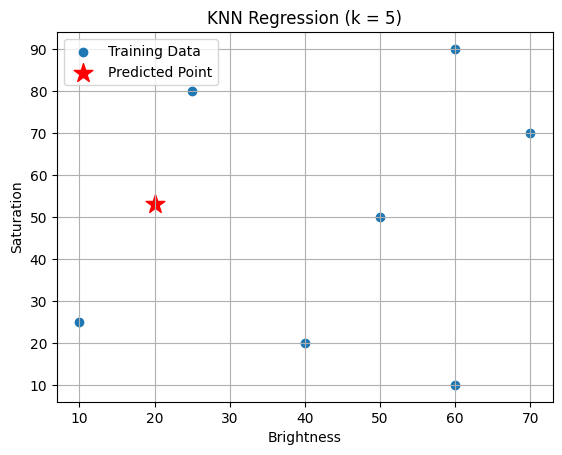

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# -----------------------------
# Dataset
# Brightness → Feature
# Saturation → Target (Regression)
# -----------------------------
data = np.array([
    [40, 20],
    [50, 50],
    [60, 90],
    [10, 25],
    [70, 70],
    [60, 10],
    [25, 80]
])

# Feature (Brightness)
X = data[:, 0].reshape(-1, 1)

# Target (Saturation)
Y = data[:, 1]

# New data point (Brightness)
new_point = np.array([[20]])

# -----------------------------
# KNN Regression
# -----------------------------
k = 5

# Euclidean distance
distances = pairwise_distances(X, new_point, metric='euclidean').flatten()

# Sort distances
indices = np.argsort(distances)

# k nearest neighbors
k_indices = indices[:k]

# Regression prediction = mean of targets
predicted_value = np.mean(Y[k_indices])

# -----------------------------
# OUTPUT
# -----------------------------
print("Metric: Euclidean Distance")
print("Distances:", distances)
print("k nearest indices:", k_indices)
print("Predicted Saturation:", predicted_value)

# -----------------------------
# PLOT
# -----------------------------
plt.scatter(X, Y, label="Training Data")
plt.scatter(new_point, predicted_value, color='red', marker='*', s=200, label="Predicted Point")
plt.xlabel("Brightness")
plt.ylabel("Saturation")
plt.title("KNN Regression (k = 5)")
plt.legend()
plt.grid()
plt.show()
